# 02 — Data Preprocessing
**Project:** IDS-KMUTT — AI-Based Intrusion Detection System  
**Dataset:** CICIDS2017 (all 7 days merged)  
**Author:** [Your name]  
**Date:** [Today's date]  

Goal: merge all CSV files, clean the data, encode labels, 
select relevant features, and apply SMOTE to fix class imbalance.  
Output: a clean dataset saved to `data/processed/` ready for model training.

## 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
from collections import Counter

print("All libraries imported successfully")

All libraries imported successfully


## 2. Load & merge all 7 files
We load each file individually to monitor memory usage,
then concatenate them into a single dataframe.

In [12]:
path = "../data/raw/CICIDS2017"
files = glob.glob(os.path.join(path, "*.csv"))

dfs = []
for f in files:
    filename = os.path.basename(f)
    temp = pd.read_csv(f, low_memory=False)
    temp.columns = temp.columns.str.strip()  # fix spaces immediately
    print(f"{filename:<60} {len(temp):>8,} rows")
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
print(f"\n Total merged dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv              225,745 rows
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv          286,467 rows
Friday-WorkingHours-Morning.pcap_ISCX.csv                     191,033 rows
Monday-WorkingHours.pcap_ISCX.csv                             529,918 rows
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv   288,602 rows
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv        170,366 rows
Tuesday-WorkingHours.pcap_ISCX.csv                            445,909 rows
Wednesday-workingHours.pcap_ISCX.csv                          692,703 rows

 Total merged dataset: 2,830,743 rows × 79 columns


## 3. Clean the data
Fix the two known CICIDS2017 issues:
- Infinite values (from division by zero during feature extraction)
- NaN values (missing data)

In [5]:
print(f"Before cleaning: {df.shape[0]:,} rows")

# Replace inf and -inf with NaN, then drop NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"After cleaning:  {df.shape[0]:,} rows")
print(f"Rows removed:    {df.shape[0] - df.shape[0]:,}")

Before cleaning: 2,830,743 rows
After cleaning:  2,827,876 rows
Rows removed:    0


## 4. Explore class distribution across all 7 days
Now that all files are merged, let's see the full picture of attack types.

In [6]:
label_counts = df['Label'].value_counts()
total = len(df)

print("Full class distribution:")
print("-" * 55)
for label, count in label_counts.items():
    bar = '█' * int((count / total) * 40)
    print(f"  {label:<35} {count:>8,}  ({count/total*100:.2f}%)")
print("-" * 55)
print(f"  {'TOTAL':<35} {total:>8,}")

Full class distribution:
-------------------------------------------------------
  BENIGN                              2,271,320  (80.32%)
  DoS Hulk                             230,124  (8.14%)
  PortScan                             158,804  (5.62%)
  DDoS                                 128,025  (4.53%)
  DoS GoldenEye                         10,293  (0.36%)
  FTP-Patator                            7,935  (0.28%)
  SSH-Patator                            5,897  (0.21%)
  DoS slowloris                          5,796  (0.20%)
  DoS Slowhttptest                       5,499  (0.19%)
  Bot                                    1,956  (0.07%)
  Web Attack � Brute Force               1,507  (0.05%)
  Web Attack � XSS                         652  (0.02%)
  Infiltration                              36  (0.00%)
  Web Attack � Sql Injection                21  (0.00%)
  Heartbleed                                11  (0.00%)
-------------------------------------------------------
  TOTAL              

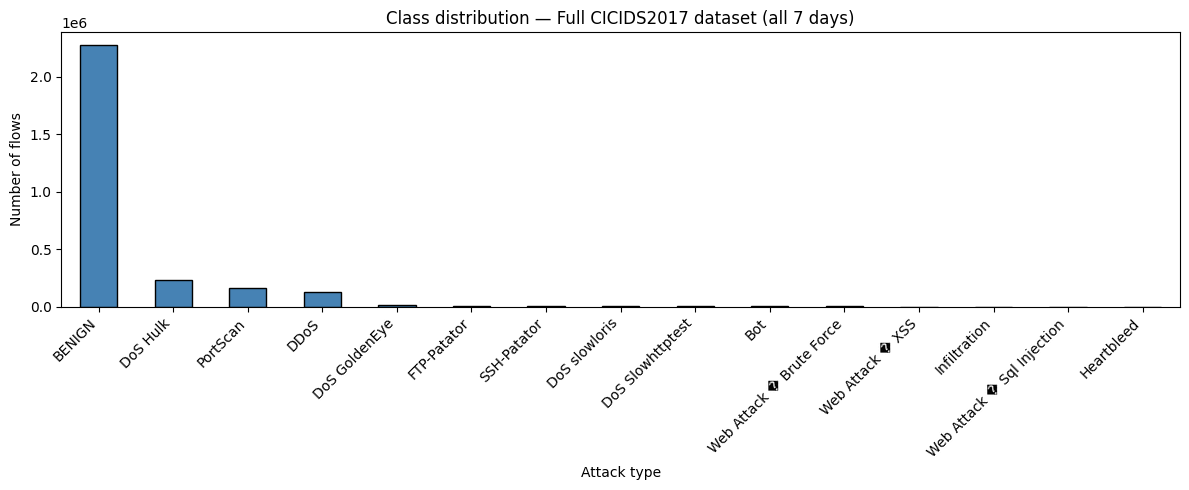

In [7]:
# Plot it
plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class distribution — Full CICIDS2017 dataset (all 7 days)')
plt.xlabel('Attack type')
plt.ylabel('Number of flows')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Encode labels
ML models work with numbers, not text.
We convert attack type names into integer codes.

Two encoding strategies:
- **Binary:** BENIGN=0, everything else=1 (normal vs attack)
- **Multiclass:** each attack type gets its own number
We keep both for flexibility during model training.

In [8]:
# Binary encoding — simplest and most useful for IDS
df['Label_binary'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Multiclass encoding
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])

# Save the mapping so we can decode predictions later
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping (multiclass):")
for name, code in label_mapping.items():
    print(f"  {name:<35} → {code}")

Label mapping (multiclass):
  BENIGN                              → 0
  Bot                                 → 1
  DDoS                                → 2
  DoS GoldenEye                       → 3
  DoS Hulk                            → 4
  DoS Slowhttptest                    → 5
  DoS slowloris                       → 6
  FTP-Patator                         → 7
  Heartbleed                          → 8
  Infiltration                        → 9
  PortScan                            → 10
  SSH-Patator                         → 11
  Web Attack � Brute Force            → 12
  Web Attack � Sql Injection          → 13
  Web Attack � XSS                    → 14


## 6. Feature selection
CICIDS2017 has 78 features. Not all of them are useful.
We remove:
- Non-numeric columns (except Label)
- Features with zero variance (same value for every row — useless)
- Highly correlated features (redundant information)

In [9]:
# Separate features and labels
X = df.drop(columns=['Label', 'Label_binary', 'Label_encoded'])
y_binary = df['Label_binary']
y_multi  = df['Label_encoded']

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])
print(f"Features before selection: {X.shape[1]}")

# Remove zero-variance features
selector = VarianceThreshold(threshold=0)
X = pd.DataFrame(selector.fit_transform(X),
                 columns=X.columns[selector.get_support()])
print(f"Features after variance filter: {X.shape[1]}")

Features before selection: 78
Features after variance filter: 70


In [10]:
# Remove highly correlated features (correlation > 0.98)
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.98)]

X.drop(columns=to_drop, inplace=True)
print(f"Features removed (high correlation): {len(to_drop)}")
print(f"Final number of features: {X.shape[1]}")
print(f"\nRemoved features: {to_drop}")

Features removed (high correlation): 20
Final number of features: 50

Removed features: ['Total Backward Packets', 'Total Length of Bwd Packets', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Idle Max', 'Idle Min']


## 7. Apply SMOTE
We apply SMOTE on the binary label version first.
SMOTE is computationally expensive on 2M+ rows.
I will run this cell on the HPC cluster, not my your local PC.

In [ ]:
print(f"Before SMOTE: {Counter(y_binary)}")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y_binary)

print(f"After SMOTE:  {Counter(y_resampled)}")
print(f"\nTotal rows after SMOTE: {len(X_resampled):,}")

## 8. Save the processed dataset
Save the clean, balanced dataset to `data/processed/`
so we can load it directly in notebooks 03, 04, and 05
without repeating all these steps.

In [11]:
os.makedirs("../data/processed/", exist_ok=True)

df_processed = X.copy()
df_processed['Label_binary'] = y_binary.values
df_processed['Label_encoded'] = y_multi.values

df_processed.to_csv("../data/processed/cicids2017_cleaned_nosmote.csv", index=False)
print(f"Saved without SMOTE — {df_processed.shape[0]:,} rows")

Saved without SMOTE — 2,827,876 rows


## Conclusions

| Step | Status | Result |
|---|---|---|
| Files merged | Done | 7 CSV files → 2,827,876 rows |
| Cleaning (inf, NaN, spaces) | Done | 2,867 rows removed (<0.1%) |
| Label encoding | Done | 15 classes encoded (binary + multiclass) |
| Variance filter | Done | 78 → 70 features (8 removed) |
| Correlation filter | Done | 70 → 50 features (20 removed) |
| SMOTE balancing | Pending | Requires HPC access |
| Output saved | Done | `data/processed/cicids2017_cleaned_nosmote.csv` |

### Key findings

**Class imbalance is severe and must be addressed**  
BENIGN traffic dominates at 80.32% (2,271,320 flows). A naive model 
predicting BENIGN for every flow would score 80% accuracy while detecting 
zero attacks — the classic accuracy paradox. SMOTE is mandatory before 
training any model.

**Three rare classes will be challenging**  
Heartbleed (11 samples), SQL Injection (21 samples), and Infiltration 
(36 samples) are too rare for reliable model learning even after SMOTE. 
Detection performance on these classes should be interpreted with caution 
in the evaluation phase.

**Feature reduction improves efficiency without information loss**  
The feature space was reduced from 78 to 50 by removing constant features 
(variance filter) and redundant correlated pairs (correlation > 0.98). 
This reduces training time significantly with no loss of discriminative power.

**Note on encoding**  
The `?` characters in Web Attack label names are a known UTF-8 issue 
with CICIDS2017 on Windows. This does not affect model training.

### Pending
- [ ] Run SMOTE on HPC cluster → save `cicids2017_cleaned.csv`
- [ ] Validate SMOTE output — check balanced class distribution

